### For our Project (Just paste all of the rest things in Terminal)

First, we will use PDBFixer to clean the structure and add missing hydrogens at a physiological pH (7.4): 

### TO DO
1. In 'config.txt', find center(x,y,z), select 'box size'
2. Prepare Receptor
   - Download the receptor (MMP-1), change the name in the second cell
   - Use PDBFixer to clean the structure. For us, we have to add Ca2+, Zn2+
   - In the Third cell, change 'A:203' to the correct part according to where Zn2+ is in!
   - Download 20 ligands we will use in the 'ligands_raw' folder as ligand_raw_{#}.sdf
     - REMEMBER: Make a separate chart for yourself to know the name of the ligands (e.g. ligand_1: Batimastat)

### IN NOTEBOOK

In [21]:
import csv
import pandas as pd
import matplotlib.pyplot as plt

# Extract only the table into a CSV file
def extract_result(input_file, csv_file): 
    with open(input_file, 'r') as f:
        lines = f.readlines()

    data_rows = []
    start_collecting = False
    
    for line in lines:
        if '-----+' in line:
            start_collecting = True
            continue
        
        if start_collecting and line.strip():
            parts = line.split()
            if parts and parts[0].isdigit():
                data_rows.append(parts[1:])

    with open(csv_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['affinity', 'rmsd_lb', 'rmsd_ub'])
        writer.writerows(data_rows)

In [ ]:
n=20 #number of ligands

In [31]:
for i in range(1, n+1):
    extract_result(f'./results/log_ligand_{i}.txt', f'./table_results/table_ligand_{i}.csv')
    #table_list.append(f'table_ligand_{i}.csv')

In [32]:
#Extract the affinity of mode 1 into a dictionary
best_affinity = {}

for i in range(1, n+1):
    df = pd.read_csv(f'./table_results/table_ligand_{i}.csv')
    best_affinity.update({f'ligand_{i}' : df['affinity'].iloc[0]})
    
print(best_affinity)

#Sort 20 ligands from lowest to highest affinity
sort_affinity = dict(sorted(best_affinity.items(), key=lambda item: item[1]))

print(sort_affinity)

{'ligand_1': np.float64(-8.207), 'ligand_2': np.float64(-9.121), 'ligand_3': np.float64(-9.121)}
{'ligand_2': np.float64(-9.121), 'ligand_3': np.float64(-9.121), 'ligand_1': np.float64(-8.207)}


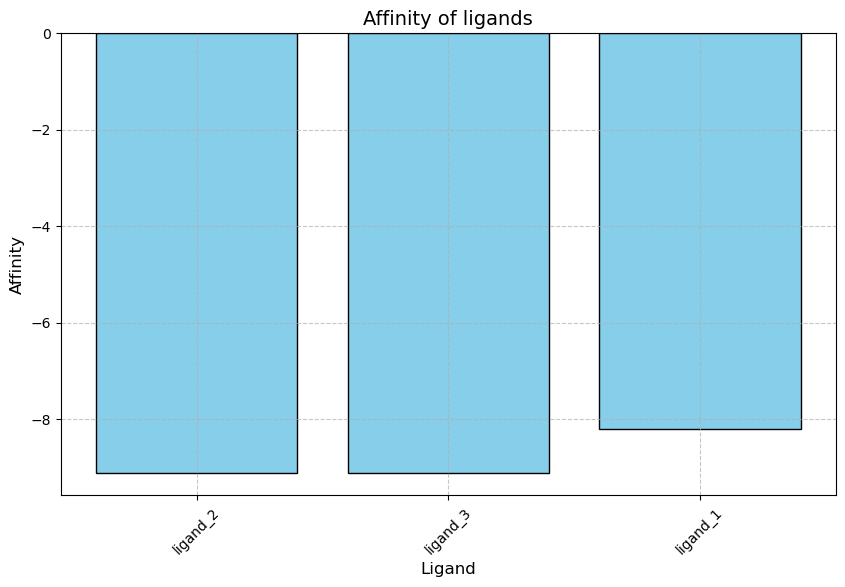

In [33]:
#Show the affinity of all 20 ligands
plt.figure(figsize=(10, 6))

plt.bar(sort_affinity.keys(), sort_affinity.values(), color='skyblue', edgecolor='black')

plt.title('Best affinity of ligands (kcal/mol)', fontsize=14)
plt.xlabel('Ligand', fontsize=12)
plt.ylabel('Affinity', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

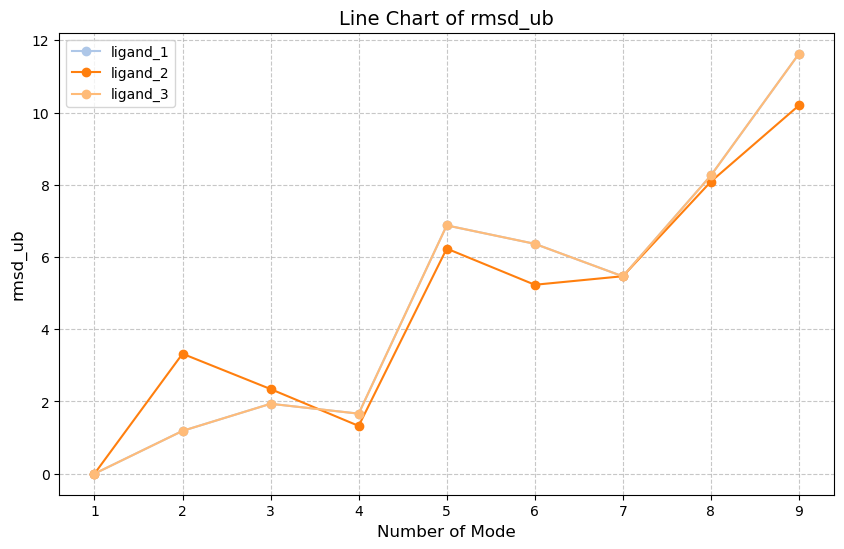

In [34]:
#Plot rmsd_ub of all 20 ligands
plt.figure(figsize=(10, 6))

cmap = plt.cm.tab20
for i in range(1, n+1):
    df = pd.read_csv(f'./table_results/table_ligand_{i}.csv')
    plt.plot(df['rmsd_ub'] , marker='o', linestyle='-', color=cmap(i), label=f'ligand_{i}')

plt.title(f'Line Chart of rmsd_ub', fontsize=14)
plt.xlabel('Number of Mode', fontsize=12)
plt.ylabel('rmsd_ub', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.xticks(range(9), range(1, 10))
plt.show()

### From lab 5

In [ ]:
mk_prepare_receptor.py -i beta2ar_receptorH.pdb -o flex_receptor -p -v \ 
#mk_prepare_receptor.py -i beta2ar_receptorH.pdb (name of the receptor we are using) -o flex_receptor -p -v \ 
--box_center 64.610 17.949 12.734 \ #Find the point of Zn2+
--box_size 25.0 25.0 25.0 \ #Set the size based on the paper
-f A:203 -a #Find 1~3 places

In [ ]:
vina --config config.txt \
--receptor flex_receptor_rigid.pdbqt \
--flex flex_receptor_flex.pdbqt \
--exhaustiveness 18 \
--out output_flex.pdbqt | tee log_flex.txt

In [ ]:
mk_export.py output_flex.pdbqt -s output_flex_poses_withflex.sdf -k

In [ ]:
vina --config config.txt --out output.pdbqt | tee log.txt

In [4]:
import sys
print(sys.executable)

/home/dan/miniconda3/envs/vina/bin/python


### Trying to do with Python..

In [2]:
import os

ligand_dir = './ligands'
result_dir = './results'
config_file = 'config.txt'

if not os.path.exists(result_dir):
    os.makedirs(result_dir)

In [3]:
!mk_prepare_receptor.py -i beta2ar_receptorH.pdb -o flex_receptor -p -v --box_center 64.610 17.949 12.734 --box_size 25.0 25.0 25.0 -f A:203 -a 

No module named 'prody'
option --read_with_prody requires Prody, which is not installed.
Installable from PyPI (pip install prody) or conda-forge (micromamba install prody)


Checkpoint: you have both flex_receptor_rigid.pdbqt and flex_receptor_flex.pdbqt, plus
flex_receptor.box.txt.

mk_prepare_receptor.py -i beta2ar_receptorH.pdb -o flex_receptor -p -v \ 
#mk_prepare_receptor.py -i beta2ar_receptorH.pdb (name of the receptor we are using) -o flex_receptor -p -v \ 
--box_center 64.610 17.949 12.734 \ #Find the point of Zn2+
--box_size 25.0 25.0 25.0 \ #Set the size based on the paper
-f A:203 -a #Find 1~3 places

In [5]:
for i in range(1, 2):

    !vina --config config.txt \
          --receptor flex_receptor_rigid.pdbqt \
          --flex flex_receptor_flex.pdbqt \
          --ligand ./ligands/ligand_{i}.pdbqt \
          --exhaustiveness 18 \
          --out ./results/output_ligand_{i}.pdbqt | tee ./results/log_ligand_{i}.txt

    !mk_export.py ./results/output_ligand_{i}.pdbqt -s ./results/output_visual_ligand_{i}.sdf -k

/bin/bash: line 1: vina: command not found
Traceback (most recent call last):
  File "/home/dan/miniconda3/bin/mk_export.py", line 7, in <module>
    sys.exit(main())
             ~~~~^^
  File "/home/dan/miniconda3/lib/python3.13/site-packages/meeko/cli/mk_export.py", line 94, in main
    with open(filename) as f:
         ~~~~^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: './results/output_ligand_1.pdbqt'


In [5]:
for i in range(1, 2):
    ligand_name = f"ligand_{i}.pdbqt"
    input_path = os.path.join(ligand_dir, ligand_name)

    output_pdbqt = os.path.join(result_dir, f"output_ligand_{i}.pdbqt")
    log_file = os.path.join(result_dir, f"log_ligand_{i}.txt")
    output_sdf = os.path.join(result_dir, f"output_visual_ligand_{i}.sdf")

    !vina --config {config_file} \
          --receptor flex_receptor_rigid.pdbqt \
          --flex flex_receptor_flex.pdbqt \
          --ligand {input_path} \
          --exhaustiveness 18 \
          --out {output_pdbqt} | tee {log_file}

    !mk_export.py {output_pdbqt} -s {output_sdf} -k

/bin/bash: line 1: vina: command not found
Traceback (most recent call last):
  File "/home/dan/miniconda3/bin/mk_export.py", line 7, in <module>
    sys.exit(main())
             ~~~~^^
  File "/home/dan/miniconda3/lib/python3.13/site-packages/meeko/cli/mk_export.py", line 94, in main
    with open(filename) as f:
         ~~~~^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: './results/output_ligand_1.pdbqt'


In [ ]:
for i in range(1, 21):
    ligand_name = f"ligand_{i}.pdbqt"
    input_path = os.path.join(ligand_dir, ligand_name)

    output_pdbqt = os.path.join(result_dir, f"output_ligand_{i}.pdbqt")
    log_file = os.path.join(result_dir, f"log_ligand_{i}.txt")
    output_sdf = os.path.join(result_dir, f"output_visual_ligand_{i}.sdf")

    !vina --config {config_file} \
          --receptor flex_receptor_rigid.pdbqt \
          --flex flex_receptor_flex.pdbqt \
          --ligand {input_path} \
          --exhaustiveness 18 \
          --out {output_pdbqt} | tee {log_file}

    !mk_export.py {output_pdbqt} -s {output_sdf} -k

Checkpoint: output_ligand{i}.pdbqt and log_ligand{i}.txt, output_visual_ligand{i} were created.